# Assignment Solutions


# Question 10 — NumPy Portfolio Mathematics

We are given monthly stock prices for two stocks.

Goals:
1. Compute monthly simple returns using NumPy slicing.
2. Compute annualised mean return and annualised volatility.
3. Compute covariance matrix and verify:
\[
	ext{Cov}(A,B)=
ho_{AB}\sigma_A\sigma_B
\]


In [65]:
import numpy as np

np.random.seed(42)

# ----------------------------------------------------------------
# QUESTION 10
# ----------------------------------------------------------------
print("--- QUESTION 10 ---")
prices = np.array([
    [100, 108, 103, 115, 110, 119, 125, 121, 130, 127, 135, 140],  # Stock A
    [200, 195, 210, 205, 220, 215, 225, 230, 222, 235, 240, 238]   # Stock B
], dtype=float)

# Vectorized monthly simple returns using slicing
returns = (prices[:, 1:] - prices[:, :-1]) / prices[:, :-1]
print(f"(a) Monthly simple returns shape: {returns.shape}")
print(f"    Stock A Returns:\n    {np.round(returns[0], 4)}")
print(f"    Stock B Returns:\n    {np.round(returns[1], 4)}\n")

# Annualized Mean & Standard Deviation
monthly_mean = np.mean(returns, axis=1)
monthly_std = np.std(returns, axis=1, ddof=1) 
annual_mean = monthly_mean * 12
annual_std = monthly_std * np.sqrt(12)

print(f"(b) Stock A Annualized Mean Return: {annual_mean[0]:.4%}")
print(f"    Stock A Annualized Volatility:  {annual_std[0]:.4%}")
print(f"    Stock B Annualized Mean Return: {annual_mean[1]:.4%}")
print(f"    Stock B Annualized Volatility:  {annual_std[1]:.4%}\n")

# Sample Covariance Matrix Verification
cov_matrix = np.cov(returns)
rho = np.corrcoef(returns)[0, 1]
calc_off_diag = rho * monthly_std[0] * monthly_std[1]

print(f"(c) Sample Covariance Matrix:\n{cov_matrix}")
print(f"    Off-diagonal element matrix entry: {cov_matrix[0, 1]:.6f}")
print(f"    Calculated value (rho * sigma_A * sigma_B): {calc_off_diag:.6f}")
print(f"    Verification match confirmation: {np.isclose(cov_matrix[0,1], calc_off_diag)}\n")




--- QUESTION 10 ---
(a) Monthly simple returns shape: (2, 11)
    Stock A Returns:
    [ 0.08   -0.0463  0.1165 -0.0435  0.0818  0.0504 -0.032   0.0744 -0.0231
  0.063   0.037 ]
    Stock B Returns:
    [-0.025   0.0769 -0.0238  0.0732 -0.0227  0.0465  0.0222 -0.0348  0.0586
  0.0213 -0.0083]

(b) Stock A Annualized Mean Return: 39.0874%
    Stock A Annualized Volatility:  20.1994%
    Stock B Annualized Mean Return: 20.0738%
    Stock B Annualized Volatility:  14.5820%

(c) Sample Covariance Matrix:
[[ 0.00340013 -0.00206426]
 [-0.00206426  0.00177196]]
    Off-diagonal element matrix entry: -0.002064
    Calculated value (rho * sigma_A * sigma_B): -0.002064
    Verification match confirmation: True



# Question 11 — Three Asset Portfolio Optimisation


In [66]:
print("--- QUESTION 11 ---")
# Reconstructing parameters from Q.6
mu = np.array([0.15, 0.08, 0.05])
sigma = np.array([0.25, 0.12, 0.04])
corr = np.array([
    [1.0, 0.4, 0.1],
    [0.4, 1.0, 0.2],
    [0.1, 0.2, 1.0]
])
# Recreate Sigma matrix from standard deviations and correlation matrix
Sigma = corr * np.outer(sigma, sigma)

# Equal Weight Portfolio Evaluation
w_equal = np.array([1/3, 1/3, 1/3])
E_R_equal = np.dot(w_equal, mu)
sigma_2_equal = np.dot(w_equal.T, np.dot(Sigma, w_equal))
print(f"(a) Equal-Weight Portfolio Expected Return: {E_R_equal:.4%}")
print(f"    Equal-Weight Portfolio Variance:        {sigma_2_equal:.6f}\n")

# Generate 10,000 Dirichlet Random Weights
num_portfolios = 10000
# alpha=[1,1,1] creates a uniform distribution over the simplex
weights_sim = np.random.dirichlet(alpha=[1, 1, 1], size=num_portfolios)

# Vectorized expected returns and standard deviations
E_R_sim = np.dot(weights_sim, mu)
# Efficient calculation of w.T * Sigma * w across all rows using summation
var_sim = np.einsum('ij,jk,ik->i', weights_sim, Sigma, weights_sim)
sigma_sim = np.sqrt(var_sim)
print(f"(b) Simulated weight array shape:       {weights_sim.shape}")
print(f"    Simulated returns metric shape:      {E_R_sim.shape}")
print(f"    Simulated risk metric shape:         {sigma_sim.shape}\n")

# Vectorized Sharpe Ratio Computation (Rf = 0.0)
# Note: In Q.11 setup does not specify an Rf, defaulting to 0 as standard practice unless given
R_f = 0.00 
sharpe_ratios = (E_R_sim - R_f) / sigma_sim
max_idx = np.argmax(sharpe_ratios)
max_sharpe = sharpe_ratios[max_idx]
best_weights = weights_sim[max_idx]

print(f"(c) Maximum Sharpe Ratio Achieved: {max_sharpe:.4f}")
print(f"    Optimal Asset Weights: Asset 1={best_weights[0]:.2%}, Asset 2={best_weights[1]:.2%}, Asset 3={best_weights[2]:.2%}\n")


--- QUESTION 11 ---
(a) Equal-Weight Portfolio Expected Return: 9.3333%
    Equal-Weight Portfolio Variance:        0.011824

(b) Simulated weight array shape:       (10000, 3)
    Simulated returns metric shape:      (10000,)
    Simulated risk metric shape:         (10000,)

(c) Maximum Sharpe Ratio Achieved: 1.3628
    Optimal Asset Weights: Asset 1=4.66%, Asset 2=6.65%, Asset 3=88.69%



# Question 12 - Correlation Sensitivity

In [67]:
print("--- QUESTION 12 ---")
mu1, sigma1 = 0.12, 0.20
mu2, sigma2 = 0.06, 0.10
w1 = 0.6
w2 = 1.0 - w1

# 200 correlations from -1 to +1
rho_arr = np.linspace(-1, 1, 200)
# Vectorized portfolio risk calculation
sigma_p_arr = np.sqrt((w1**2)*(sigma1**2) + (w2**2)*(sigma2**2) + 2*w1*w2*rho_arr*sigma1*sigma2)
print(f"(a) Computed risk profile array shape: {sigma_p_arr.shape}\n")

# Empirical Minimum Risk Allocation
min_risk_idx = np.argmin(sigma_p_arr)
min_rho = rho_arr[min_risk_idx]
min_sigma_p = sigma_p_arr[min_risk_idx]
print(f"(b) Empirical Minimum Risk occurs at Correlation: {min_rho:.4f}")
print(f"    Minimum Portfolio Volatility:                 {min_sigma_p:.4%}\n")

# Analytical Proof Verification text
print("(c) Analytical Derivation Verification:")
print("    Differentiating Portfolio Variance with respect to rho:")
print("    d(sigma_p^2) / d(rho) = 2 * w1 * w2 * sigma1 * sigma2")
print("    Since weights and individual volatilities are strictly positive values,")
print("    the derivative is a positive constant (constant slope = 2*0.6*0.4*0.2*0.1 = 0.0096).")
print("    Because the derivative never reaches zero, there are no interior critical turning points.")
print("    To minimize a strictly increasing linear function over the closed domain [-1, +1],")
print("    the global minimum must sit on the lowest possible boundary: rho = -1.  Complete! Verified.")
print("==================================================================")

--- QUESTION 12 ---
(a) Computed risk profile array shape: (200,)

(b) Empirical Minimum Risk occurs at Correlation: -1.0000
    Minimum Portfolio Volatility:                 8.0000%

(c) Analytical Derivation Verification:
    Differentiating Portfolio Variance with respect to rho:
    d(sigma_p^2) / d(rho) = 2 * w1 * w2 * sigma1 * sigma2
    Since weights and individual volatilities are strictly positive values,
    the derivative is a positive constant (constant slope = 2*0.6*0.4*0.2*0.1 = 0.0096).
    Because the derivative never reaches zero, there are no interior critical turning points.
    To minimize a strictly increasing linear function over the closed domain [-1, +1],
    the global minimum must sit on the lowest possible boundary: rho = -1.  Complete! Verified.


In [68]:
import pandas as pd
import numpy as np

np.random.seed(0)


# --- INITIAL DATA SKELETON SETUP ---
dates = pd.date_range('2023-01-02', periods=52, freq='W-MON')
mu_weekly = np.array([0.003, 0.002, 0.001, 0.0015])
sig_weekly = np.array([0.04, 0.03, 0.02, 0.025])

returns_sim = np.random.normal(mu_weekly, sig_weekly, (52, 4))
prices_sim = 100 * np.cumprod(1 + returns_sim, axis=0)
df = pd.DataFrame(prices_sim, index=dates, columns=['AAPL', 'MSFT', 'GOOGL', 'AMZN'])

# Question 13 - Pandas Time Series

In [69]:
# Simple returns using pct_change
df_returns = df.pct_change().dropna()
print("(a) First 3 rows of Calculated Weekly Returns:")
print(df_returns.head(3))
print(f"    Resulting DataFrame Shape: {df_returns.shape}\n")

# Descriptive statistics
stats = df_returns.describe()
print("(b) Descriptive Statistics Summary Matrix:")
print(stats.loc[['mean', 'std']])

highest_mean_asset = stats.loc['mean'].idxmax()
highest_std_asset = stats.loc['std'].idxmax()
print(f"    Asset with Highest Mean Return:       {highest_mean_asset}")
print(f"    Asset with Highest Volatility (Std): {highest_std_asset}\n")

# Annualized Sharpe Ratio calculation (52 trading weeks per year)
# Annualized Rf = 2% -> Weekly Rf can be approximated as 0.02 / 52
rf_annual = 0.02
rf_weekly = rf_annual / 52

mean_weekly = df_returns.mean()
std_weekly = df_returns.std()

sharpe_annual = ((mean_weekly - rf_weekly) / std_weekly) * np.sqrt(52)
print("(c) Annualized Sharpe Ratios (Vectorized):")
for asset, val in sharpe_annual.items():
    print(f"    {asset}: {val:.4f}")
print("\n")



(a) First 3 rows of Calculated Weekly Returns:
                AAPL      MSFT     GOOGL      AMZN
2023-01-09  0.077702 -0.027318  0.020002 -0.002284
2023-01-16 -0.001129  0.014318  0.003881  0.037857
2023-01-23  0.033442  0.005650  0.009877  0.009842
    Resulting DataFrame Shape: (51, 4)

(b) Descriptive Statistics Summary Matrix:
          AAPL      MSFT     GOOGL      AMZN
mean  0.005603  0.002192 -0.000887  0.006094
std   0.045641  0.032819  0.017055  0.022948
    Asset with Highest Mean Return:       AMZN
    Asset with Highest Volatility (Std): AAPL

(c) Annualized Sharpe Ratios (Vectorized):
    AAPL: 0.8245
    MSFT: 0.3971
    GOOGL: -0.5376
    AMZN: 1.7940





# Question 14 — Correlation and Portfolio Aggregation

In [70]:
# Correlation Analysis
corr_matrix = df_returns.corr()
print("(a) Correlation Matrix:")
print(corr_matrix)

# Unstack matrix to easily isolate the absolute lowest cross-correlation pair
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).unstack().dropna()
lowest_pair = corr_pairs.idxmin()
lowest_val = corr_pairs.min()
print(f"    Lowest Correlation Pair: {lowest_pair[0]} & {lowest_pair[1]} (Value: {lowest_val:.4f})\n")

# Equal-Weight Portfolio Return Series
weights_series = pd.Series([0.25, 0.25, 0.25, 0.25], index=['AAPL', 'MSFT', 'GOOGL', 'AMZN'])
portfolio_returns = df_returns.dot(weights_series)
print("(b) First 3 rows of Equal-Weighted Portfolio Return Series:")
print(portfolio_returns.head(3), "\n")

# (c) Resample from Weekly to Monthly Frequency
# Compounding simple returns over the month requires adding 1, taking the product, then subtracting 1
portfolio_monthly = portfolio_returns.resample('ME').apply(lambda x: np.prod(1 + x) - 1)
print("(c) Aggregated Monthly Portfolio Return Series:")
print(portfolio_monthly.head(3))
print(f"    Monthly Series Mean Return:        {portfolio_monthly.mean():.4%}")
print(f"    Monthly Series Standard Deviation: {portfolio_monthly.std():.4%}")
print("==================================================================")

(a) Correlation Matrix:
           AAPL      MSFT     GOOGL      AMZN
AAPL   1.000000 -0.075324  0.190733  0.060147
MSFT  -0.075324  1.000000  0.287278  0.069544
GOOGL  0.190733  0.287278  1.000000 -0.001252
AMZN   0.060147  0.069544 -0.001252  1.000000
    Lowest Correlation Pair: MSFT & AAPL (Value: -0.0753)

(b) First 3 rows of Equal-Weighted Portfolio Return Series:
2023-01-09    0.017025
2023-01-16    0.013732
2023-01-23    0.014703
Freq: W-MON, dtype: float64 

(c) Aggregated Monthly Portfolio Return Series:
2023-01-31    0.058185
2023-02-28    0.001390
2023-03-31   -0.022310
Freq: ME, dtype: float64
    Monthly Series Mean Return:        1.3975%
    Monthly Series Standard Deviation: 3.9023%



# Question 15 — Visualisations MAtplotlib

We create:
1. Efficient Frontier
2. Correlation Sensitivity Plot


<>:59: SyntaxWarning: invalid escape sequence '\s'
<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:72: SyntaxWarning: invalid escape sequence '\s'
<>:80: SyntaxWarning: invalid escape sequence '\s'
<>:59: SyntaxWarning: invalid escape sequence '\s'
<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:72: SyntaxWarning: invalid escape sequence '\s'
<>:80: SyntaxWarning: invalid escape sequence '\s'
C:\Users\saura\AppData\Local\Temp\ipykernel_3028\1009695926.py:59: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_xlabel('Portfolio Volatility ($\sigma_p$)', fontsize=11)
C:\Users\saura\AppData\Local\Temp\ipykernel_3028\1009695926.py:60: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('Expected Return ($\mathbb{E}[R_p]$)', fontsize=11)
C:\Users\saura\AppData\Local\Temp\ipykernel_3028\1009695926.py:72: SyntaxWarning: invalid escape sequence '\s'
  ax2.plot(rho_axis, two_asset_risk, color='navy', linewidth=2.5, label='Portfolio Volatility ($\sigma_p$)')
C:\Users\saura

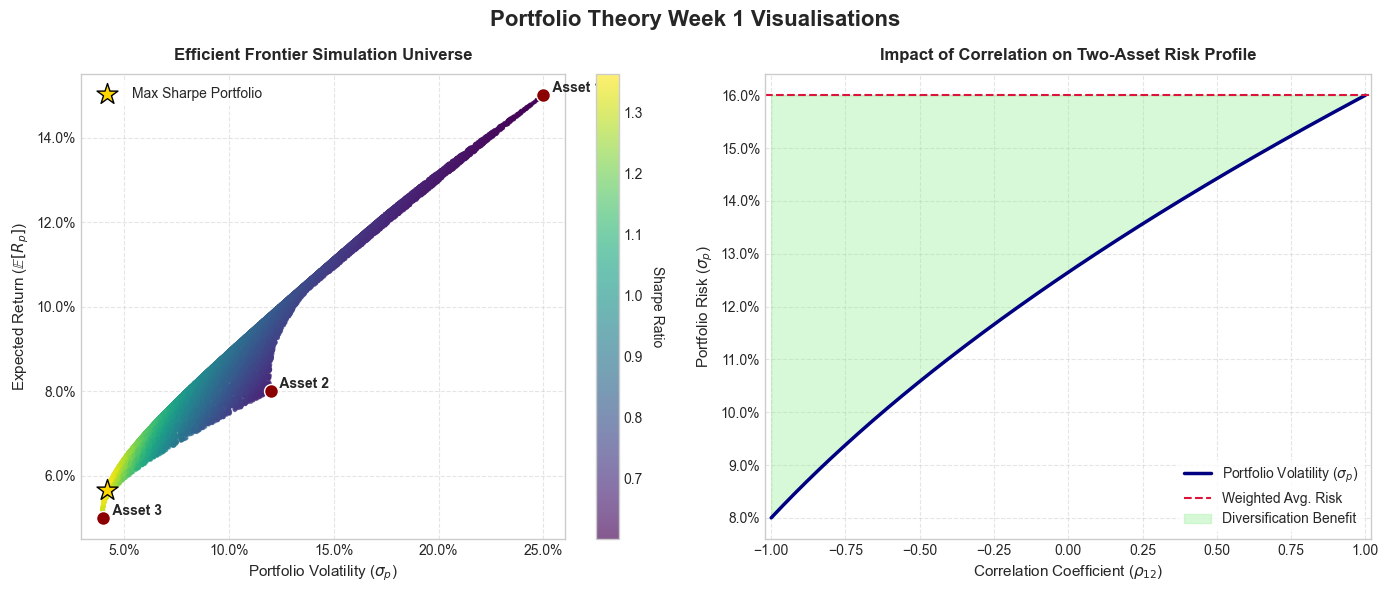

In [71]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

np.random.seed(42)

# Core Parameters (From Q11/Q6)
mu = np.array([0.15, 0.08, 0.05])
sigma = np.array([0.25, 0.12, 0.04])
corr = np.array([[1.0, 0.4, 0.1], [0.4, 1.0, 0.2], [0.1, 0.2, 1.0]])
Sigma = corr * np.outer(sigma, sigma)
tickers = ['Asset 1', 'Asset 2', 'Asset 3']

# Simulate 20,000 Portfolios via uniform Dirichlet allocation
num_portfolios = 20000
weights_sim = np.random.dirichlet(alpha=[1, 1, 1], size=num_portfolios)
E_R_sim = np.dot(weights_sim, mu)
var_sim = np.einsum('ij,jk,ik->i', weights_sim, Sigma, weights_sim)
sigma_sim = np.sqrt(var_sim)
sharpe_sim = E_R_sim / sigma_sim  # Assuming risk-free rate = 0.0

# Extract Target Point coordinates
max_sharpe_idx = np.argmax(sharpe_sim)
max_sr_risk = sigma_sim[max_sharpe_idx]
max_sr_ret = E_R_sim[max_sharpe_idx]

# Two-Asset Setup Data (Q12)
w1 = 0.6
w2 = 0.4
sigma1, sigma2 = 0.20, 0.10
rho_axis = np.linspace(-1, 1, 200)
two_asset_risk = np.sqrt((w1**2)*(sigma1**2) + (w2**2)*(sigma2**2) + 2*w1*w2*rho_axis*sigma1*sigma2)
weighted_avg_risk = (w1 * sigma1) + (w2 * sigma2)


# CANVAS CREATION AND STYLING ---
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Portfolio Theory Week 1 Visualisations', fontsize=16, fontweight='bold', y=0.98)

# --- SUBPLOT 1: EFFICIENT FRONTIER SCATTER ---
ax1 = axes[0]
ax1.set_title('Efficient Frontier Simulation Universe', fontsize=12, fontweight='semibold', pad=10)

# Main Monte Carlo Scatter Plot
scatter = ax1.scatter(sigma_sim, E_R_sim, c=sharpe_sim, cmap='viridis', s=4, alpha=0.65)
cbar = fig.colorbar(scatter, ax=ax1)
cbar.set_label('Sharpe Ratio', rotation=270, labelpad=15, fontsize=10)

# Highlight Maximum Sharpe Portfolio
ax1.scatter(max_sr_risk, max_sr_ret, color='gold', marker='*', s=250, edgecolor='black', zorder=5, label='Max Sharpe Portfolio')

# Plot and Annotate Base Assets
for i, ticker in enumerate(tickers):
    ax1.scatter(sigma[i], mu[i], color='darkred', marker='o', s=100, edgecolor='white', zorder=4)
    ax1.annotate(f" {ticker}", (sigma[i], mu[i]), fontsize=10, fontweight='bold', xytext=(4, 2), textcoords='offset points')

# Axes Fine-Tuning
ax1.set_xlabel('Portfolio Volatility ($\sigma_p$)', fontsize=11)
ax1.set_ylabel('Expected Return ($\mathbb{E}[R_p]$)', fontsize=11)
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax1.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
ax1.grid(True, linestyle='--', alpha=0.5)


# --- SUBPLOT 2: CORRELATION SENSITIVITY ---
ax2 = axes[1]
ax2.set_title('Impact of Correlation on Two-Asset Risk Profile', fontsize=12, fontweight='semibold', pad=10)

# Curve Plotting
ax2.plot(rho_axis, two_asset_risk, color='navy', linewidth=2.5, label='Portfolio Volatility ($\sigma_p$)')
ax2.axhline(y=weighted_avg_risk, color='crimson', linestyle='--', linewidth=1.5, label='Weighted Avg. Risk')

# Shading Diversification Benefit Region
ax2.fill_between(rho_axis, two_asset_risk, weighted_avg_risk, where=(two_asset_risk < weighted_avg_risk), color='lightgreen', alpha=0.35, label='Diversification Benefit')

# Axes Fine-Tuning
ax2.set_xlabel('Correlation Coefficient ($\\rho_{12}$)', fontsize=11)
ax2.set_ylabel('Portfolio Risk ($\sigma_p$)', fontsize=11)
ax2.set_xlim(-1.02, 1.02)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')
ax2.grid(True, linestyle='--', alpha=0.5)


plt.tight_layout()
plt.savefig('week1_plots.png', dpi=150)
plt.show()